# Special Extra!!

Getting the best models on the planet to generate an SVG

Inspired by the legendary Simon Willison's Pelican riding a bike test

Key point: this is a very different task to image generation! The model needs to describe the image with lines and shapes.

### This uses OpenRouter.ai so that we easily access the latest models

In [1]:
from dotenv import load_dotenv
from IPython.display import Markdown, display
from datetime import datetime
import time
from revealer import reveal
from openai import OpenAI
import os
load_dotenv(override=True)

True

In [6]:
load_dotenv(override=True)

openai_api_key = os.getenv('OPENAI_API_KEY')
if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")
    
MODEL_GPT_4_1_MINI = "gpt-4.1-mini"
MODEL_GPT_4_1 = "gpt-4.1"
MODEL_GPT_5_4_NANO = "gpt-5.4-nano"
openai = OpenAI()

OpenAI API Key exists and begins sk-proj-


In [3]:
challenge = "a panda rollerblading to work"
prompt = f"Generate an SVG of {challenge}. Respond with the SVG only, no code blocks."
messages = [{"role": "user", "content": prompt}]

In [10]:
def artist(model):
    try:
        start = datetime.now()
        response = openai.chat.completions.create(model=model, messages=messages)
        result = response.choices[0].message.content
        end = datetime.now()
        elapsed = (end - start).total_seconds()
        heading = f"### {model}\n**Time:** {elapsed // 60:.0f} min {elapsed % 60:.0f} s\n\n"
    except Exception as e:
        print(f"Model {model} failed: {e}")
        heading = f"### {model}\n**Error:** {e}\n\n"
        return heading, None
    return heading, result

In [11]:
results = [
    artist(MODEL_GPT_4_1_MINI),
    artist(MODEL_GPT_4_1),
    artist(MODEL_GPT_5_4_NANO),
]

### gpt-4.1-mini
**Time:** 0 min 27 s



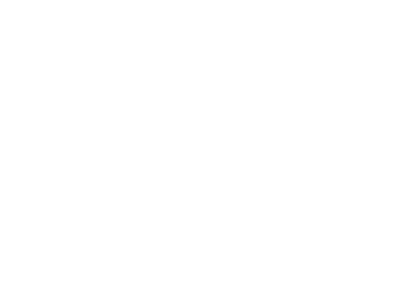

### gpt-4.1
**Time:** 0 min 9 s



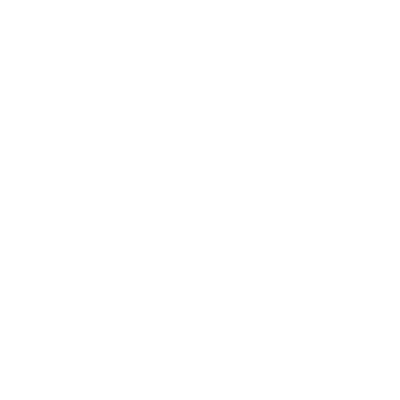

### gpt-5.4-nano
**Time:** 0 min 23 s



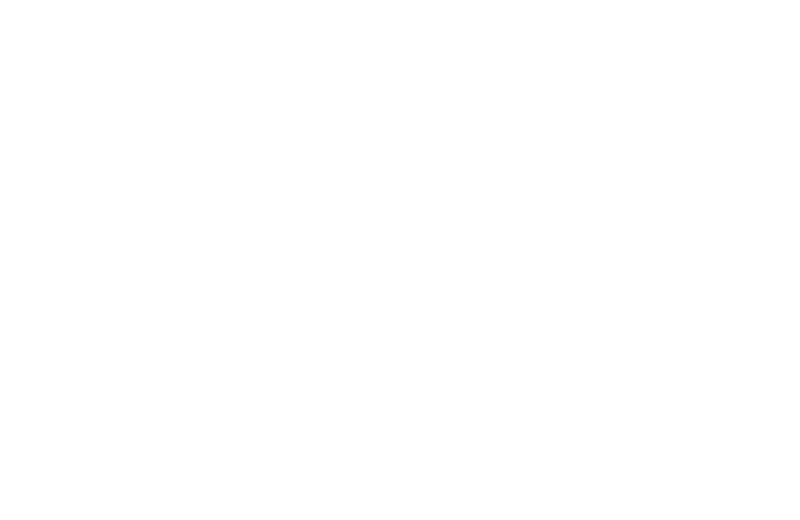

In [12]:
for result in results:
    try:
        display(Markdown(result[0]))
        reveal(result[1])
        time.sleep(12)
    except Exception as e:
        print(f"Error displaying result: {e}")

## In Week 4 we will have more scientific ways to compare models..

but this was quite fun.